# Задание 11. Версионирование модели кластеризации текста

## Задания
1. Установка библиотек
2. Импорт и конфигурация
3. Функции
4. Загрузка данных
5. Очистка текста
6. Эмбеддинги
7. Снижение размерности
8. Подбор числа кластеров
9. Финальная кластеризация и метрики
10. Логирование в MLflow и регистрация модели
11. Итог


# Задание 1. Установка библиотек

Устанавливаем библиотеки, которые используются в ноутбуке для эмбеддингов, кластеризации, визуализации и логирования эксперимента в DAGsHub через MLflow.


In [28]:
!pip -q install mlflow dagshub sentence-transformers umap-learn scikit-learn


# Задание 2. Импорт и конфигурация

Подготавливаем импорты, константы эксперимента и параметры подключения к MLflow на DAGsHub.


In [29]:
import json
import os
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import umap.umap_ as umap
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    f1_score,
    normalized_mutual_info_score,
    silhouette_score,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
DATASET_REMOVE = ("headers", "footers", "quotes")
DATASET_CATEGORIES = [
    "comp.graphics",
    "comp.os.ms-windows.misc",
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware",
    "rec.autos",
    "rec.motorcycles",
    "sci.med",
    "sci.space",
]
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 64
TOP_TERMS_PER_CLUSTER = 10
DAGSHUB_USERNAME = "nepridumalnik"
DAGSHUB_REPOSITORY = "it-lms-task-11"
DAGSHUB_TOKEN = os.environ["DAGS_HUB_TOKEN"]
DAGSHUB_REPOSITORY_URL = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPOSITORY}"
TRACKING_URI = f"{DAGSHUB_REPOSITORY_URL}.mlflow"
MLFLOW_EXPERIMENT_NAME = "module_11_text_clustering_newsgroups"
MLFLOW_RUN_NAME = "newsgroups_all_minilm_umap_kmeans"
REGISTERED_MODEL_NAME = "module-11-20newsgroups-kmeans"
MODEL_ARTIFACT_PATH = "kmeans_model"

UMAP_CLUSTER_PARAMS = {
    "n_components": 10,
    "n_neighbors": 25,
    "min_dist": 0.05,
    "metric": "cosine",
    "random_state": RANDOM_STATE,
}
UMAP_VISUAL_PARAMS = {
    "n_components": 2,
    "n_neighbors": 25,
    "min_dist": 0.10,
    "metric": "cosine",
    "random_state": RANDOM_STATE,
}
KMEANS_BASE_PARAMS = {
    "random_state": RANDOM_STATE,
    "n_init": 20,
    "max_iter": 300,
}
K_CANDIDATES = list(range(max(2, len(DATASET_CATEGORIES) - 3), len(DATASET_CATEGORIES) + 4))

def resolve_module_dir() -> Path:
    """Определить каталог модуля независимо от текущей рабочей директории."""
    candidates = [Path.cwd(), Path.cwd() / "module_11"]
    for candidate in candidates:
        if (candidate / "task.ipynb").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

MODULE_DIR = resolve_module_dir()
ARTIFACT_DIR = MODULE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

config_df = pd.DataFrame(
    {
        "parameter": [
            "dagshub_repository_url",
            "tracking_uri",
            "experiment_name",
            "run_name",
            "registered_model_name",
            "embedding_model_name",
            "dataset_category_count",
            "k_candidates",
            "artifacts_dir",
            "dagshub_token_in_environment",
        ],
        "value": [
            DAGSHUB_REPOSITORY_URL,
            TRACKING_URI,
            MLFLOW_EXPERIMENT_NAME,
            MLFLOW_RUN_NAME,
            REGISTERED_MODEL_NAME,
            EMBEDDING_MODEL_NAME,
            len(DATASET_CATEGORIES),
            str(K_CANDIDATES),
            str(ARTIFACT_DIR),
            bool(DAGSHUB_TOKEN),
        ],
    }
)

display(config_df)


,parameter,value
0,dagshub_repository_url,https://dagshub.com/nepridumalnik/it-lms-task-11
1,tracking_uri,https://dagshub.com/nepridumalnik/it-lms-task-11.mlflow
2,experiment_name,module_11_text_clustering_newsgroups
3,run_name,newsgroups_all_minilm_umap_kmeans
4,registered_model_name,module-11-20newsgroups-kmeans
5,embedding_model_name,sentence-transformers/all-MiniLM-L6-v2
6,dataset_category_count,8
7,k_candidates,"[5, 6, 7, 8, 9, 10, 11]"
8,artifacts_dir,D:\Programming\Python\it-lms\module_11\artifacts
9,dagshub_token_in_environment,True


# Задание 3. Функции

Основные этапы пайплайна оформлены в виде функций с docstring, чтобы параметры можно было явно передавать в расчёты и логирование MLflow.


In [30]:
def clean_text(text: str) -> str:
    """Удалить перевод строки, табуляцию, URL, email и нормализовать пробелы."""
    cleaned = text.replace("\n", " ").replace("\t", " ")
    cleaned = re.sub(r"https?://\S+|www\.\S+", " ", cleaned)
    cleaned = re.sub(r"[\w.+-]+@[\w-]+\.[\w.-]+", " ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()


def truncate_text(text: str, limit: int = 180) -> str:
    """Обрезать длинный текст для компактного табличного вывода."""
    return text if len(text) <= limit else text[:limit] + "..."


def load_newsgroups_dataset(categories: list[str], subset: str = "train") -> pd.DataFrame:
    """Загрузить выбранные темы 20 Newsgroups и вернуть DataFrame."""
    dataset = fetch_20newsgroups(
        subset=subset,
        categories=categories,
        remove=DATASET_REMOVE,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return pd.DataFrame(
        {
            "raw_text": dataset.data,
            "target": dataset.target,
            "target_name": [dataset.target_names[index] for index in dataset.target],
        }
    )


def build_text_embeddings(
    texts: pd.Series,
    model_name: str,
    batch_size: int,
) -> np.ndarray:
    """Построить эмбеддинги текста моделью sentence-transformers."""
    text_list = texts.fillna("").astype(str).tolist()
    try:
        model = SentenceTransformer(model_name, device="cpu")
        embeddings = model.encode(
            text_list,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
    except Exception as exc:
        raise RuntimeError(
            f"Не удалось загрузить модель '{model_name}' из sentence-transformers и построить эмбеддинги."
        ) from exc
    return np.asarray(embeddings, dtype=np.float32)


def fit_umap_projection(
    embeddings: np.ndarray,
    reducer_params: dict[str, Any],
) -> tuple[umap.UMAP, np.ndarray]:
    """Обучить UMAP и получить reduced-представление."""
    reducer = umap.UMAP(**reducer_params)
    reduced = reducer.fit_transform(embeddings)
    return reducer, reduced


def purity_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Вычислить purity по кластерным меткам."""
    total = 0
    for cluster_id in np.unique(y_pred):
        cluster_mask = y_pred == cluster_id
        _, counts = np.unique(y_true[cluster_mask], return_counts=True)
        total += counts.max()
    return float(total / len(y_true))


def align_cluster_labels(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Сопоставить cluster ids истинным классам через Hungarian matching."""
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)
    contingency = np.zeros((len(true_labels), len(pred_labels)), dtype=int)

    for row_index, true_label in enumerate(true_labels):
        for col_index, pred_label in enumerate(pred_labels):
            contingency[row_index, col_index] = np.sum(
                (y_true == true_label) & (y_pred == pred_label)
            )

    row_ind, col_ind = linear_sum_assignment(contingency.max() - contingency)
    mapping = {pred_labels[col]: true_labels[row] for row, col in zip(row_ind, col_ind)}

    for pred_label in pred_labels:
        if pred_label not in mapping:
            cluster_true = y_true[y_pred == pred_label]
            values, counts = np.unique(cluster_true, return_counts=True)
            mapping[pred_label] = values[counts.argmax()]

    return np.array([mapping[label] for label in y_pred])


def evaluate_clustering(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    features: np.ndarray,
) -> dict[str, float]:
    """Посчитать внутренние и внешние метрики кластеризации."""
    aligned_pred = align_cluster_labels(y_true, y_pred)
    return {
        "silhouette": float(silhouette_score(features, y_pred)),
        "calinski_harabasz": float(calinski_harabasz_score(features, y_pred)),
        "davies_bouldin": float(davies_bouldin_score(features, y_pred)),
        "ari": float(adjusted_rand_score(y_true, y_pred)),
        "nmi": float(normalized_mutual_info_score(y_true, y_pred)),
        "purity": float(purity_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, aligned_pred)),
        "f1_macro": float(f1_score(y_true, aligned_pred, average="macro")),
    }


def search_cluster_count(
    features: np.ndarray,
    y_true: np.ndarray,
    cluster_counts: list[int],
) -> pd.DataFrame:
    """Рассчитать метрики для диапазона значений k."""
    rows: list[dict[str, float]] = []
    for cluster_count in cluster_counts:
        model = KMeans(n_clusters=cluster_count, **KMEANS_BASE_PARAMS)
        labels = model.fit_predict(features)
        metrics = evaluate_clustering(y_true, labels, features)
        rows.append(
            {
                "cluster_count": float(cluster_count),
                "silhouette": metrics["silhouette"],
                "calinski_harabasz": metrics["calinski_harabasz"],
                "davies_bouldin": metrics["davies_bouldin"],
                "ari": metrics["ari"],
                "nmi": metrics["nmi"],
                "purity": metrics["purity"],
                "accuracy": metrics["accuracy"],
                "f1_macro": metrics["f1_macro"],
            }
        )
    search_df = pd.DataFrame(rows)
    search_df["cluster_count"] = search_df["cluster_count"].astype(int)
    return search_df


def select_best_cluster_count(search_df: pd.DataFrame) -> int:
    """Выбрать лучшее k по silhouette score с детерминированным tie-break."""
    ordered = search_df.sort_values(
        ["silhouette", "calinski_harabasz", "davies_bouldin", "cluster_count"],
        ascending=[False, False, True, True],
    )
    return int(ordered.iloc[0]["cluster_count"])


def build_cluster_summary(df: pd.DataFrame, cluster_labels: np.ndarray) -> pd.DataFrame:
    """Собрать краткий профиль кластера: размер, доминирующая тема и её доля."""
    summary_df = df[["target_name"]].copy()
    summary_df["cluster"] = cluster_labels

    rows: list[dict[str, Any]] = []
    for cluster_id, cluster_part in summary_df.groupby("cluster"):
        topic_distribution = cluster_part["target_name"].value_counts(normalize=True)
        rows.append(
            {
                "cluster": int(cluster_id),
                "size": int(len(cluster_part)),
                "dominant_topic": topic_distribution.index[0],
                "dominant_share": float(topic_distribution.iloc[0]),
                "topic_count": int(cluster_part["target_name"].nunique()),
            }
        )

    return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)


def extract_top_terms_by_cluster(
    texts: pd.Series,
    cluster_labels: np.ndarray,
    top_n: int,
) -> pd.DataFrame:
    """Извлечь наиболее характерные TF-IDF-термы для каждого кластера."""
    vectorizer = TfidfVectorizer(max_features=10_000, min_df=5, stop_words="english")
    matrix = vectorizer.fit_transform(texts.fillna(""))
    feature_names = np.array(vectorizer.get_feature_names_out())

    rows: list[dict[str, Any]] = []
    for cluster_id in sorted(np.unique(cluster_labels)):
        centroid = matrix[cluster_labels == cluster_id].mean(axis=0).A1
        top_indices = centroid.argsort()[-top_n:][::-1]
        rows.append(
            {
                "cluster": int(cluster_id),
                "top_terms": ", ".join(feature_names[top_indices]),
            }
        )

    return pd.DataFrame(rows)


def build_final_metrics_table(metrics: dict[str, float]) -> pd.DataFrame:
    """Подготовить табличное представление итоговых метрик."""
    metric_group = {
        "silhouette": "internal",
        "calinski_harabasz": "internal",
        "davies_bouldin": "internal",
        "ari": "external",
        "nmi": "external",
        "purity": "external",
        "accuracy": "external",
        "f1_macro": "external",
    }
    rows = [
        {
            "metric_group": metric_group[name],
            "metric": name,
            "value": float(value),
        }
        for name, value in metrics.items()
    ]
    return pd.DataFrame(rows)


def make_cluster_search_figure(search_df: pd.DataFrame, best_k: int) -> Any:
    """Построить график подбора числа кластеров."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(search_df["cluster_count"], search_df["silhouette"], marker="o", color="#4C78A8")
    axes[0].axvline(best_k, color="#E45756", linestyle="--", label=f"best_k={best_k}")
    axes[0].set_title("Silhouette score по k")
    axes[0].set_xlabel("Число кластеров")
    axes[0].set_ylabel("Silhouette")
    axes[0].legend()

    axes[1].plot(search_df["cluster_count"], search_df["ari"], marker="o", label="ARI", color="#F58518")
    axes[1].plot(search_df["cluster_count"], search_df["nmi"], marker="o", label="NMI", color="#54A24B")
    axes[1].plot(search_df["cluster_count"], search_df["purity"], marker="o", label="Purity", color="#E45756")
    axes[1].set_title("Внешние метрики по k")
    axes[1].set_xlabel("Число кластеров")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    return fig


def make_projection_figure(projection_2d: np.ndarray, labels: np.ndarray, title: str) -> Any:
    """Построить 2D-проекцию объектов с раскраской по меткам."""
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        projection_2d[:, 0],
        projection_2d[:, 1],
        c=labels,
        s=10,
        cmap="tab10",
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    legend = ax.legend(*scatter.legend_elements(), title="Label", loc="best")
    ax.add_artist(legend)
    plt.tight_layout()
    return fig


def save_experiment_artifacts(
    search_df: pd.DataFrame,
    final_metrics_df: pd.DataFrame,
    cluster_summary_df: pd.DataFrame,
    top_terms_df: pd.DataFrame,
    projection_2d: np.ndarray,
    predicted_labels: np.ndarray,
    true_labels: np.ndarray,
    best_k: int,
    artifact_dir: Path,
) -> dict[str, Path]:
    """Сохранить таблицы и графики эксперимента в каталог артефактов."""
    artifact_paths = {
        "cluster_search_metrics": artifact_dir / "cluster_search_metrics.csv",
        "final_metrics": artifact_dir / "final_metrics.csv",
        "cluster_summary": artifact_dir / "cluster_summary.csv",
        "cluster_top_terms": artifact_dir / "cluster_top_terms.csv",
        "cluster_search_plot": artifact_dir / "cluster_search_plot.png",
        "predicted_clusters_projection": artifact_dir / "predicted_clusters_projection.png",
        "true_topics_projection": artifact_dir / "true_topics_projection.png",
    }

    search_df.to_csv(artifact_paths["cluster_search_metrics"], index=False)
    final_metrics_df.to_csv(artifact_paths["final_metrics"], index=False)
    cluster_summary_df.to_csv(artifact_paths["cluster_summary"], index=False)
    top_terms_df.to_csv(artifact_paths["cluster_top_terms"], index=False)

    search_fig = make_cluster_search_figure(search_df, best_k)
    predicted_fig = make_projection_figure(
        projection_2d,
        predicted_labels,
        "UMAP-проекция: предсказанные кластеры",
    )
    true_fig = make_projection_figure(
        projection_2d,
        true_labels,
        "UMAP-проекция: реальные темы",
    )

    search_fig.savefig(artifact_paths["cluster_search_plot"], dpi=150, bbox_inches="tight")
    predicted_fig.savefig(artifact_paths["predicted_clusters_projection"], dpi=150, bbox_inches="tight")
    true_fig.savefig(artifact_paths["true_topics_projection"], dpi=150, bbox_inches="tight")

    plt.close(search_fig)
    plt.close(predicted_fig)
    plt.close(true_fig)
    return artifact_paths


def configure_mlflow_tracking(
    username: str,
    repository: str,
    token: str,
    experiment_name: str,
) -> dict[str, Any]:
    """Настроить MLflow tracking на DAGsHub."""
    os.environ["MLFLOW_TRACKING_USERNAME"] = username
    os.environ["MLFLOW_TRACKING_PASSWORD"] = token
    os.environ["MLFLOW_TRACKING_PROJECTNAME"] = repository

    tracking_uri = f"https://dagshub.com/{username}/{repository}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
    experiment = mlflow.set_experiment(experiment_name)
    return {
        "tracking_uri": tracking_uri,
        "experiment_name": experiment_name,
        "experiment_id": experiment.experiment_id,
    }


def build_experiment_params(
    categories: list[str],
    document_count: int,
    best_k: int,
    embedding_model_name: str,
    embedding_batch_size: int,
    umap_cluster_params: dict[str, Any],
    umap_visual_params: dict[str, Any],
    k_candidates: list[int],
    top_terms_per_cluster: int,
) -> dict[str, Any]:
    """Собрать параметры эксперимента для логирования в MLflow."""
    return {
        "dataset_name": "20newsgroups_train",
        "selected_topics": ", ".join(categories),
        "topic_count": len(categories),
        "document_count": int(document_count),
        "embedding_model_name": embedding_model_name,
        "embedding_batch_size": int(embedding_batch_size),
        "umap_cluster_params": json.dumps(umap_cluster_params, sort_keys=True),
        "umap_visual_params": json.dumps(umap_visual_params, sort_keys=True),
        "k_candidates": json.dumps(k_candidates),
        "best_k": int(best_k),
        "top_terms_per_cluster": int(top_terms_per_cluster),
        "model_artifact_path": MODEL_ARTIFACT_PATH,
    }


def log_experiment_to_mlflow(
    tracking_state: dict[str, Any],
    run_name: str,
    params: dict[str, Any],
    metrics: dict[str, float],
    artifact_paths: dict[str, Path],
    final_model: KMeans,
    registered_model_name: str,
    model_artifact_path: str,
) -> dict[str, str]:
    """Залогировать параметры, метрики, артефакты и модель в MLflow, затем зарегистрировать модель."""
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        mlflow.log_metrics({name: float(value) for name, value in metrics.items()})

        for artifact_path in artifact_paths.values():
            mlflow.log_artifact(str(artifact_path), artifact_path="artifacts")

        model_info = mlflow.sklearn.log_model(final_model, name=model_artifact_path)

        run_id = run.info.run_id
        model_uri = model_info.model_uri
        registration = mlflow.register_model(
            model_uri=model_uri,
            name=registered_model_name,
            await_registration_for=180,
        )

    return {
        "run_id": run_id,
        "model_uri": model_uri,
        "registered_model_name": registration.name,
        "registered_model_version": str(registration.version),
        "tracking_uri": tracking_state["tracking_uri"],
        "experiment_name": tracking_state["experiment_name"],
    }


# Задание 4. Загрузка данных

Загружаем обучающую часть датасета 20 Newsgroups по восьми выбранным темам и смотрим на баланс классов и примеры исходных текстов.


In [31]:
news_df = load_newsgroups_dataset(DATASET_CATEGORIES)

class_distribution = (
    news_df["target_name"]
    .value_counts()
    .rename_axis("topic")
    .reset_index(name="count")
    .sort_values("topic")
    .reset_index(drop=True)
)
raw_sample_df = news_df[["target_name", "raw_text"]].head(5).copy()
raw_sample_df["raw_text"] = raw_sample_df["raw_text"].apply(truncate_text)

print("Размер датасета:", news_df.shape)
display(class_distribution)
display(raw_sample_df)


Размер датасета: (4722, 3)


,topic,count
0,comp.graphics,584
1,comp.os.ms-windows.misc,591
2,comp.sys.ibm.pc.hardware,590
3,comp.sys.mac.hardware,578
4,rec.autos,594
5,rec.motorcycles,598
6,sci.med,594
7,sci.space,593


,target_name,raw_text
0,comp.sys.mac.hardware,"\nOf course its possible, I get 1024x768 on my Centris 650. All you need is\na correctly wired video cable.\n\nGary\n\n--"
1,rec.motorcycles,\t jlevine@rd.hydro.on.ca (Jody Levine) writes...\n\n\n\n\n\n\n\n\n\tI've already discussed this in e-mail with Jonathan. It's the film...
2,comp.os.ms-windows.misc,"\n\n\n\n\n\n\n\n\n\nAll right. Not saying I know any more than the average salesguy, I'll give \nyour question a shot. \n\nThe key issu..."
3,comp.graphics,"Greetings,\n I have an Epson HI-80 4 pen plotter forsale. It emulates an HP 7570\nor 7574 - I'm not sure which. It has an option bo..."
4,rec.motorcycles,"\n\nNo, I don't watch that Bu**Sh*t.\n\n\nSo, does this mean the cop is at fault for rear-ending the bike? You know,\nfollowing too clo..."


# Задание 5. Очистка текста

Удаляем `\t`, `\n`, URL, email-адреса и нормализуем повторяющиеся пробелы. Остальной текст сохраняем без агрессивной нормализации.


In [32]:
clean_df = news_df.copy()
clean_df["clean_text"] = clean_df["raw_text"].apply(clean_text)
clean_df = clean_df.loc[clean_df["clean_text"].ne("")].reset_index(drop=True)
clean_df["raw_length"] = clean_df["raw_text"].str.len()
clean_df["clean_length"] = clean_df["clean_text"].str.len()

clean_preview_df = clean_df[["target_name", "raw_text", "clean_text", "raw_length", "clean_length"]].head(5).copy()
clean_preview_df["raw_text"] = clean_preview_df["raw_text"].apply(truncate_text)
clean_preview_df["clean_text"] = clean_preview_df["clean_text"].apply(truncate_text)

print("Размер датасета после очистки:", clean_df.shape)
display(clean_preview_df)


Размер датасета после очистки: (4575, 6)


,target_name,raw_text,clean_text,raw_length,clean_length
0,comp.sys.mac.hardware,"\nOf course its possible, I get 1024x768 on my Centris 650. All you need is\na correctly wired video cable.\n\nGary\n\n--","Of course its possible, I get 1024x768 on my Centris 650. All you need is a correctly wired video cable. Gary --",116,112
1,rec.motorcycles,\t jlevine@rd.hydro.on.ca (Jody Levine) writes...\n\n\n\n\n\n\n\n\n\tI've already discussed this in e-mail with Jonathan. It's the film...,"(Jody Levine) writes... I've already discussed this in e-mail with Jonathan. It's the film ""The Inspector General"" [:-)], with Danny Kay...",418,381
2,comp.os.ms-windows.misc,"\n\n\n\n\n\n\n\n\n\nAll right. Not saying I know any more than the average salesguy, I'll give \nyour question a shot. \n\nThe key issu...","All right. Not saying I know any more than the average salesguy, I'll give your question a shot. The key issue that I bought my BJ-200 o...",1166,1120
3,comp.graphics,"Greetings,\n I have an Epson HI-80 4 pen plotter forsale. It emulates an HP 7570\nor 7574 - I'm not sure which. It has an option bo...","Greetings, I have an Epson HI-80 4 pen plotter forsale. It emulates an HP 7570 or 7574 - I'm not sure which. It has an option board on i...",1178,1133
4,rec.motorcycles,"\n\nNo, I don't watch that Bu**Sh*t.\n\n\nSo, does this mean the cop is at fault for rear-ending the bike? You know,\nfollowing too clo...","No, I don't watch that Bu**Sh*t. So, does this mean the cop is at fault for rear-ending the bike? You know, following too closely and re...",157,151


# Задание 6. Эмбеддинги

Получаем dense-эмбеддинги очищенных текстов моделью `sentence-transformers/all-MiniLM-L6-v2`.


In [33]:
embeddings = build_text_embeddings(
    clean_df["clean_text"],
    model_name=EMBEDDING_MODEL_NAME,
    batch_size=EMBEDDING_BATCH_SIZE,
)

embedding_summary_df = pd.DataFrame(
    {
        "field": ["embedding_model_name", "embedding_batch_size", "embeddings_shape"],
        "value": [
            EMBEDDING_MODEL_NAME,
            EMBEDDING_BATCH_SIZE,
            str(embeddings.shape),
        ],
    }
)

display(embedding_summary_df)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12718.99it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 72/72 [00:37<00:00,  1.91it/s]


,field,value
0,embedding_model_name,sentence-transformers/all-MiniLM-L6-v2
1,embedding_batch_size,64
2,embeddings_shape,"(4575, 384)"


# Задание 7. Снижение размерности

Строим представление для кластеризации через UMAP и отдельно готовим 2D-проекцию для визуального анализа.


In [34]:
cluster_reducer, reduced_embeddings = fit_umap_projection(embeddings, UMAP_CLUSTER_PARAMS)
visual_reducer, projection_2d = fit_umap_projection(embeddings, UMAP_VISUAL_PARAMS)

reduction_summary_df = pd.DataFrame(
    {
        "field": ["cluster_reduced_shape", "projection_2d_shape", "umap_cluster_params", "umap_visual_params"],
        "value": [
            str(reduced_embeddings.shape),
            str(projection_2d.shape),
            json.dumps(UMAP_CLUSTER_PARAMS, sort_keys=True),
            json.dumps(UMAP_VISUAL_PARAMS, sort_keys=True),
        ],
    }
)

display(reduction_summary_df)


d:\Programming\Python\it-lms\.venv2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\Programming\Python\it-lms\.venv2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,field,value
0,cluster_reduced_shape,"(4575, 10)"
1,projection_2d_shape,"(4575, 2)"
2,umap_cluster_params,"{""metric"": ""cosine"", ""min_dist"": 0.05, ""n_components"": 10, ""n_neighbors"": 25, ""random_state"": 42}"
3,umap_visual_params,"{""metric"": ""cosine"", ""min_dist"": 0.1, ""n_components"": 2, ""n_neighbors"": 25, ""random_state"": 42}"


# Задание 8. Подбор числа кластеров

Перебираем диапазон `число тем ± 3`, сохраняем таблицу по всем `k` и выбираем лучшее значение по `silhouette score`.


Реальное число тем: 8
Лучшее число кластеров по silhouette: 5


,cluster_count,silhouette,calinski_harabasz,davies_bouldin,ari,nmi,purity,accuracy,f1_macro
0,5,0.495,"11,816.093",0.782,0.442,0.568,0.545,0.545,0.431
1,6,0.473,"11,079.054",0.872,0.428,0.541,0.550,0.550,0.474
2,7,0.463,"10,497.505",0.893,0.451,0.558,0.603,0.603,0.565
3,8,0.446,"10,360.910",0.917,0.465,0.571,0.602,0.602,0.598
4,9,0.412,"10,522.901",0.972,0.439,0.557,0.638,0.638,0.638
5,10,0.404,"10,146.340",0.990,0.439,0.548,0.644,0.644,0.643
6,11,0.411,"9,941.516",1.006,0.426,0.537,0.636,0.636,0.632


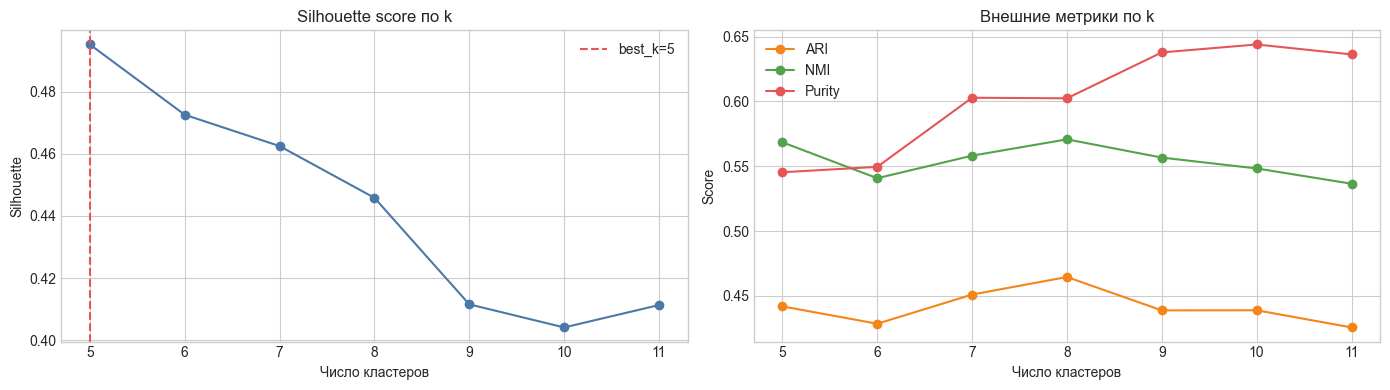

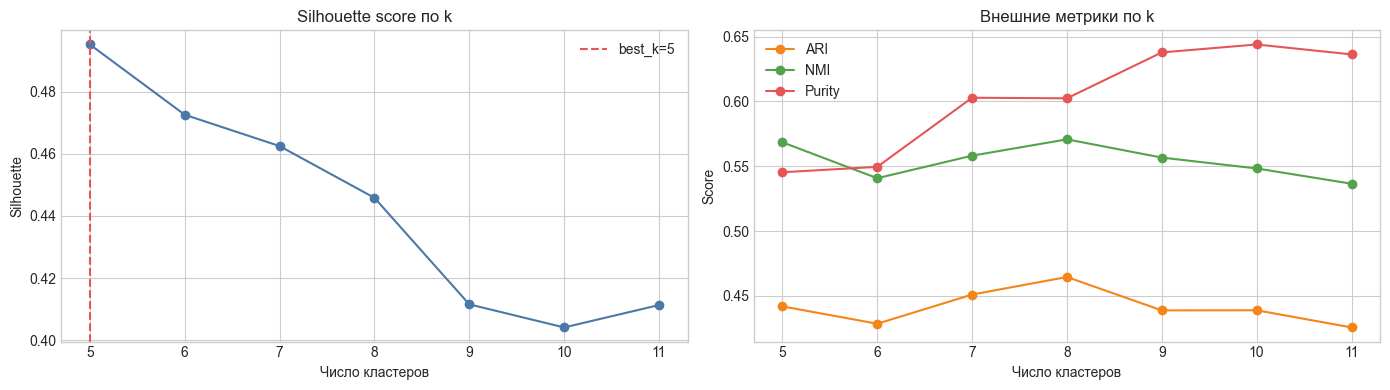

In [35]:
search_df = search_cluster_count(
    reduced_embeddings,
    clean_df["target"].to_numpy(),
    K_CANDIDATES,
)
best_k = select_best_cluster_count(search_df)
search_fig = make_cluster_search_figure(search_df, best_k)

print("Реальное число тем:", len(DATASET_CATEGORIES))
print("Лучшее число кластеров по silhouette:", best_k)
display(search_df)
display(search_fig)


# Задание 9. Финальная кластеризация и метрики

Обучаем финальную модель `KMeans` с выбранным числом кластеров, считаем внутренние и внешние метрики, строим проекции и профили кластеров.


,metric_group,metric,value
0,internal,silhouette,0.495
1,internal,calinski_harabasz,"11,816.093"
2,internal,davies_bouldin,0.782
3,external,ari,0.442
4,external,nmi,0.568
5,external,purity,0.545
6,external,accuracy,0.545
7,external,f1_macro,0.431


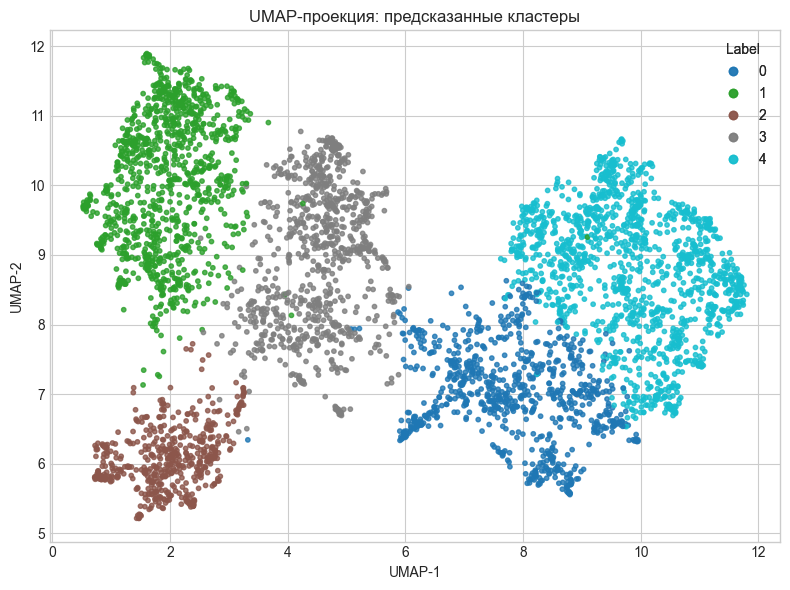

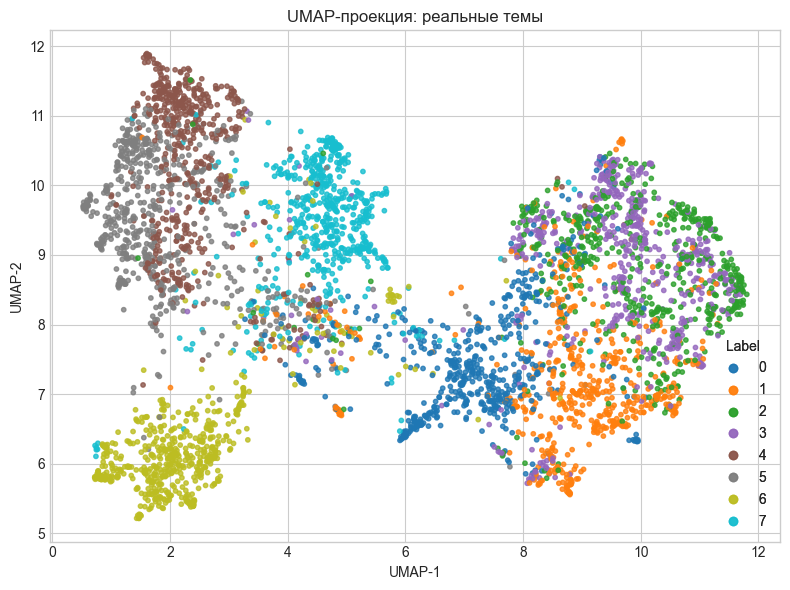

,cluster,size,dominant_topic,dominant_share,topic_count
0,0,832,comp.graphics,0.512,7
1,1,1049,rec.autos,0.485,7
2,2,520,sci.med,0.965,5
3,3,845,sci.space,0.621,8
4,4,1329,comp.sys.ibm.pc.hardware,0.401,7


,cluster,top_terms
0,0,"windows, files, file, thanks, program, ftp, use, graphics, know, does"
1,1,"car, bike, like, just, cars, don, good, know, right, engine"
2,2,"msg, gordon, banks, skepticism, chastity, n3jxp, shameful, intellect, surrender, soon"
3,3,"space, like, just, nasa, know, orbit, think, launch, moon, people"
4,4,"card, drive, scsi, windows, problem, does, use, thanks, mac, know"


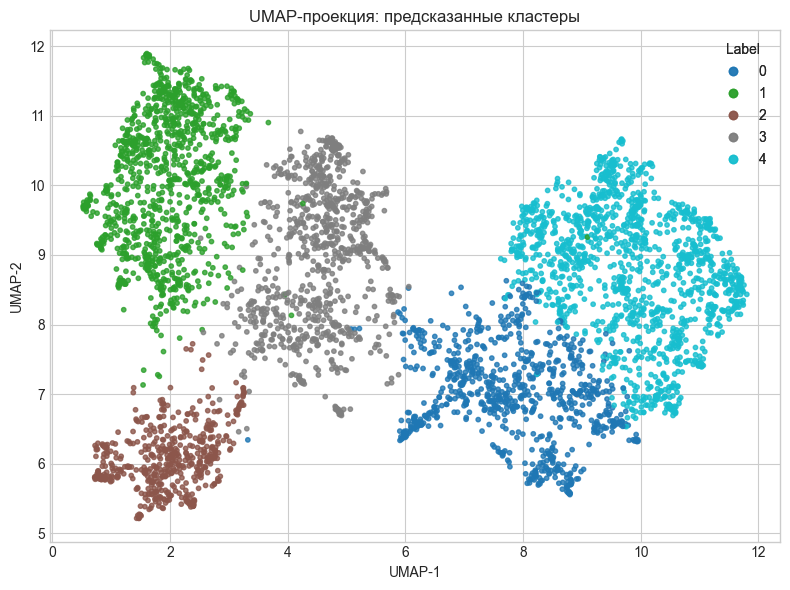

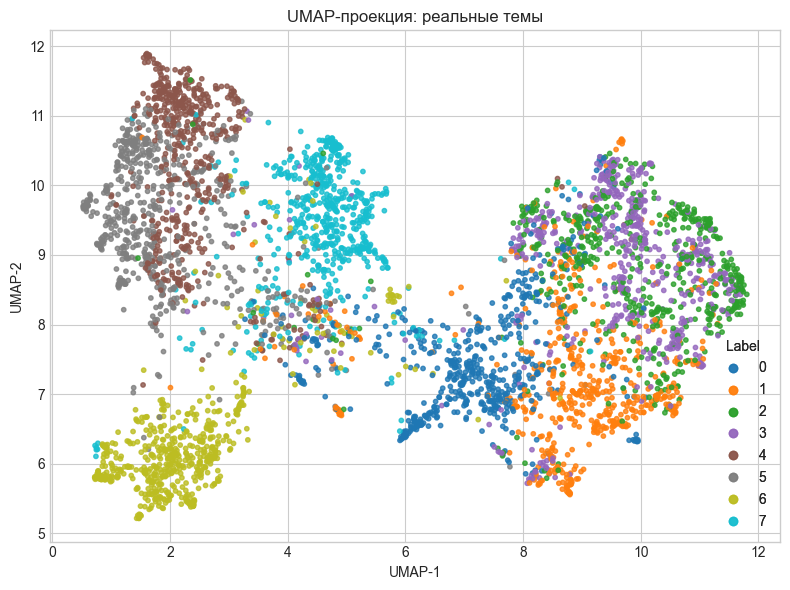

In [36]:
final_model = KMeans(n_clusters=best_k, **KMEANS_BASE_PARAMS)
predicted_labels = final_model.fit_predict(reduced_embeddings)
final_metrics = evaluate_clustering(
    clean_df["target"].to_numpy(),
    predicted_labels,
    reduced_embeddings,
)
final_metrics_df = build_final_metrics_table(final_metrics)

predicted_fig = make_projection_figure(
    projection_2d,
    predicted_labels,
    "UMAP-проекция: предсказанные кластеры",
)
true_fig = make_projection_figure(
    projection_2d,
    clean_df["target"].to_numpy(),
    "UMAP-проекция: реальные темы",
)
cluster_summary_df = build_cluster_summary(clean_df, predicted_labels)
top_terms_df = extract_top_terms_by_cluster(
    clean_df["clean_text"],
    predicted_labels,
    top_n=TOP_TERMS_PER_CLUSTER,
)

display(final_metrics_df)
display(predicted_fig)
display(true_fig)
display(cluster_summary_df)
display(top_terms_df)


# Задание 10. Логирование в MLflow и регистрация модели

Настраиваем tracking URI на `nepridumalnik/it-lms-task-11`, сохраняем артефакты, логируем параметры, метрики, артефакты и модель, затем регистрируем модель в MLflow Model Registry.


In [37]:
tracking_state = configure_mlflow_tracking(
    username=DAGSHUB_USERNAME,
    repository=DAGSHUB_REPOSITORY,
    token=DAGSHUB_TOKEN,
    experiment_name=MLFLOW_EXPERIMENT_NAME,
)
artifact_paths = save_experiment_artifacts(
    search_df=search_df,
    final_metrics_df=final_metrics_df,
    cluster_summary_df=cluster_summary_df,
    top_terms_df=top_terms_df,
    projection_2d=projection_2d,
    predicted_labels=predicted_labels,
    true_labels=clean_df["target"].to_numpy(),
    best_k=best_k,
    artifact_dir=ARTIFACT_DIR,
)
experiment_params = build_experiment_params(
    categories=DATASET_CATEGORIES,
    document_count=len(clean_df),
    best_k=best_k,
    embedding_model_name=EMBEDDING_MODEL_NAME,
    embedding_batch_size=EMBEDDING_BATCH_SIZE,
    umap_cluster_params=UMAP_CLUSTER_PARAMS,
    umap_visual_params=UMAP_VISUAL_PARAMS,
    k_candidates=K_CANDIDATES,
    top_terms_per_cluster=TOP_TERMS_PER_CLUSTER,
)
tracking_result = log_experiment_to_mlflow(
    tracking_state=tracking_state,
    run_name=MLFLOW_RUN_NAME,
    params=experiment_params,
    metrics=final_metrics,
    artifact_paths=artifact_paths,
    final_model=final_model,
    registered_model_name=REGISTERED_MODEL_NAME,
    model_artifact_path=MODEL_ARTIFACT_PATH,
)

artifact_list_df = pd.DataFrame(
    {
        "artifact_name": list(artifact_paths.keys()),
        "artifact_path": [str(path) for path in artifact_paths.values()],
    }
)
tracking_summary_df = pd.DataFrame(
    {
        "field": [
            "tracking_uri",
            "experiment_name",
            "experiment_id",
            "run_id",
            "model_uri",
            "registered_model_name",
            "registered_model_version",
        ],
        "value": [
            tracking_result["tracking_uri"],
            tracking_result["experiment_name"],
            tracking_state["experiment_id"],
            tracking_result["run_id"],
            tracking_result["model_uri"],
            tracking_result["registered_model_name"],
            tracking_result["registered_model_version"],
        ],
    }
)

display(artifact_list_df)
display(tracking_summary_df)


2026/04/18 10:21:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'module-11-20newsgroups-kmeans' already exists. Creating a new version of this model...
2026/04/18 10:21:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 180 seconds for model version to finish creation. Model name: module-11-20newsgroups-kmeans, version 2
Created version '2' of model 'module-11-20newsgroups-kmeans'.


🏃 View run newsgroups_all_minilm_umap_kmeans at: https://dagshub.com/nepridumalnik/it-lms-task-11.mlflow/#/experiments/0/runs/bfb2df84c02e44d8aa59c066a1aaf7b4
🧪 View experiment at: https://dagshub.com/nepridumalnik/it-lms-task-11.mlflow/#/experiments/0


,artifact_name,artifact_path
0,cluster_search_metrics,D:\Programming\Python\it-lms\module_11\artifacts\cluster_search_metrics.csv
1,final_metrics,D:\Programming\Python\it-lms\module_11\artifacts\final_metrics.csv
2,cluster_summary,D:\Programming\Python\it-lms\module_11\artifacts\cluster_summary.csv
3,cluster_top_terms,D:\Programming\Python\it-lms\module_11\artifacts\cluster_top_terms.csv
4,cluster_search_plot,D:\Programming\Python\it-lms\module_11\artifacts\cluster_search_plot.png
5,predicted_clusters_projection,D:\Programming\Python\it-lms\module_11\artifacts\predicted_clusters_projection.png
6,true_topics_projection,D:\Programming\Python\it-lms\module_11\artifacts\true_topics_projection.png


,field,value
0,tracking_uri,https://dagshub.com/nepridumalnik/it-lms-task-11.mlflow
1,experiment_name,module_11_text_clustering_newsgroups
2,experiment_id,0
3,run_id,bfb2df84c02e44d8aa59c066a1aaf7b4
4,model_uri,models:/m-697ba076187a42eaa0b20c4021a06613
5,registered_model_name,module-11-20newsgroups-kmeans
6,registered_model_version,2


# Задание 11. Итог

1. Для датасета 20 Newsgroups выполнены загрузка, очистка текста, построение эмбеддингов, снижение размерности и кластеризация.
2. Подбор числа кластеров выполнен в диапазоне `число тем ± 3`, а лучшее значение выбрано по `silhouette score`.
3. Рассчитаны обязательные внутренние метрики (`silhouette`, `calinski_harabasz`, `davies_bouldin`) и не менее трёх внешних метрик (`ari`, `nmi`, `purity`, `accuracy`, `f1_macro`).
4. В MLflow на DAGsHub залогированы параметры, метрики, артефакты и модель `KMeans`.
5. Модель зарегистрирована в MLflow Model Registry, а ключевые идентификаторы запуска выведены ниже.


In [38]:
final_output_df = pd.DataFrame(
    {
        "field": [
            "dagshub_repository_url",
            "tracking_uri",
            "experiment_name",
            "run_id",
            "model_uri",
            "registered_model_name",
        ],
        "value": [
            DAGSHUB_REPOSITORY_URL,
            tracking_result["tracking_uri"],
            tracking_result["experiment_name"],
            tracking_result["run_id"],
            tracking_result["model_uri"],
            tracking_result["registered_model_name"],
        ],
    }
)

display(final_output_df)


,field,value
0,dagshub_repository_url,https://dagshub.com/nepridumalnik/it-lms-task-11
1,tracking_uri,https://dagshub.com/nepridumalnik/it-lms-task-11.mlflow
2,experiment_name,module_11_text_clustering_newsgroups
3,run_id,bfb2df84c02e44d8aa59c066a1aaf7b4
4,model_uri,models:/m-697ba076187a42eaa0b20c4021a06613
5,registered_model_name,module-11-20newsgroups-kmeans
